# Test: do xG (deserved-performance) ratings beat goals ratings for international teams?

Builds a goals-based Elo and an xG-based Elo over StatsBomb open-data tournaments, then checks which predicts future results better.

Idea: a team that creates the better chances but loses is probably stronger than the scoreline says; xG should capture that.

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 7
plt.rcParams["figure.figsize"] = (8, 4)


## Load the StatsBomb international xG dataset

Reads the cached CSV if present; otherwise rebuilds it from StatsBomb open data (needs statsbombpy and network).

In [2]:
CSV_CANDIDATES = ["statsbomb_intl_xg.csv", "data/raw/statsbomb/intl_xg_matches.csv"]
path = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)

if path is None:
    from statsbombpy import sb
    targets = [(43,3,"WC 2018"),(43,106,"WC 2022"),(55,43,"Euro 2020"),
               (55,282,"Euro 2024"),(223,282,"Copa 2024"),(1267,107,"AFCON 2023")]
    rows = []
    for cid, sid, tag in targets:
        for m in sb.matches(competition_id=cid, season_id=sid).itertuples():
            ev = sb.events(match_id=m.match_id); sh = ev[ev["type"] == "Shot"]
            rows.append({"match_id": m.match_id, "tournament": tag, "date": m.match_date,
                         "home": m.home_team, "away": m.away_team,
                         "home_goals": int(m.home_score), "away_goals": int(m.away_score),
                         "home_xg": round(float(sh[sh.team==m.home_team]["shot_statsbomb_xg"].sum()), 3),
                         "away_xg": round(float(sh[sh.team==m.away_team]["shot_statsbomb_xg"].sum()), 3)})
    d = pd.DataFrame(rows)
    os.makedirs("data/raw/statsbomb", exist_ok=True)
    d.to_csv("data/raw/statsbomb/intl_xg_matches.csv", index=False)
else:
    d = pd.read_csv(path)

d["date"] = pd.to_datetime(d["date"])
d = d.sort_values("date").reset_index(drop=True)
print(f"{len(d)} matches, {d.date.min().date()} -> {d.date.max().date()}")
print(d["tournament"].value_counts().to_string())
d.head()


314 matches, 2018-06-14 -> 2024-07-15
tournament
WC 2018       64
WC 2022       64
AFCON 2023    52
Euro 2020     51
Euro 2024     51
Copa 2024     32


,match_id,tournament,date,home,away,home_goals,away_goals,home_xg,away_xg
0,7525,WC 2018,2018-06-14,Russia,Saudi Arabia,5,0,1.282,0.249
1,7576,WC 2018,2018-06-15,Portugal,Spain,3,3,1.435,1.661
2,7577,WC 2018,2018-06-15,Morocco,Iran,0,1,1.059,0.698
3,7578,WC 2018,2018-06-15,Egypt,Uruguay,0,1,0.364,1.941
4,7532,WC 2018,2018-06-16,Peru,Denmark,0,1,1.926,1.122


### How do goals compare with xG across these tournaments?

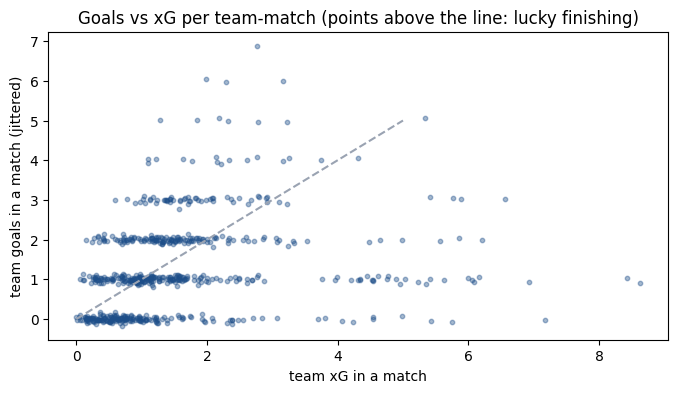

mean goals 1.26 vs mean xG 1.53 per team-match


In [3]:
g = pd.concat([d["home_goals"], d["away_goals"]]).to_numpy()
x = pd.concat([d["home_xg"], d["away_xg"]]).to_numpy()
fig, ax = plt.subplots()
ax.scatter(x, g + np.random.normal(0, 0.06, len(g)), s=10, alpha=0.4, color="#1d4e89")
ax.plot([0, 5], [0, 5], "--", color="#9aa3b2")
ax.set_xlabel("team xG in a match"); ax.set_ylabel("team goals in a match (jittered)")
ax.set_title("Goals vs xG per team-match (points above the line: lucky finishing)")
plt.show()
print("mean goals %.2f vs mean xG %.2f per team-match" % (g.mean(), x.mean()))


### Build three forward-in-time ratings: goals, xG, and a 50/50 blend

Each rating updates after every match; goals uses the scoreline, xG uses the share of expected goals (the deserved result).

In [4]:
def run_elo(df, mode, K=40):
    r = defaultdict(lambda: 1500.0)
    diffs = []
    for m in df.itertuples():
        r1, r2 = r[m.home], r[m.away]
        diffs.append(r1 - r2)
        e1 = 1 / (10 ** (-(r1 - r2) / 400) + 1)
        res = 1.0 if m.home_goals > m.away_goals else (0.5 if m.home_goals == m.away_goals else 0.0)
        tot = m.home_xg + m.away_xg
        xshare = m.home_xg / tot if tot > 0 else 0.5
        s1 = {"goals": res, "xg": xshare, "blend": 0.5 * res + 0.5 * xshare}[mode]
        delta = K * (s1 - e1)
        r[m.home] = r1 + delta
        r[m.away] = r2 - delta
    return np.array(diffs), dict(r)

d["y"] = np.where(d.home_goals > d.away_goals, 0, np.where(d.home_goals == d.away_goals, 1, 2))
ratings = {}
for mode in ("goals", "xg", "blend"):
    d[f"diff_{mode}"], ratings[mode] = run_elo(d, mode)
d[["home", "away", "diff_goals", "diff_xg", "y"]].head()


,home,away,diff_goals,diff_xg,y
0,Russia,Saudi Arabia,0.0,0.0,0
1,Portugal,Spain,0.0,0.0,1
2,Morocco,Iran,0.0,0.0,2
3,Egypt,Uruguay,0.0,0.0,2
4,Peru,Denmark,0.0,0.0,2


### Does the xG rating predict future results better than the goals rating?

Train the rating-to-outcome mapping on matches before June 2024, then score held-out log-loss on the 2024 Euro and Copa America.

train 231 matches, test 83 (2024 Euro + Copa)


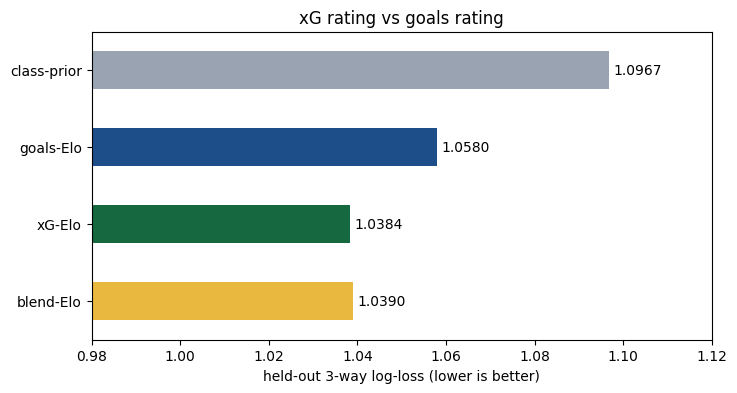

class-prior    1.0967
goals-Elo      1.0580
xG-Elo         1.0384
blend-Elo      1.0390
Name: held-out log-loss, dtype: float64

In [5]:
split = pd.Timestamp("2024-06-01")
tr, te = d[d.date < split], d[d.date >= split]

def logloss(p, y):
    return float(-np.mean(np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1))))

def heldout_logloss(col):
    Xtr = np.r_[tr[[col]].values, -tr[[col]].values]
    ytr = np.r_[tr.y.values, tr.y.map({0: 2, 1: 1, 2: 0}).values]
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    model.fit(Xtr, ytr)
    return logloss(model.predict_proba(te[[col]].values), te.y.values)

prior = tr.y.value_counts(normalize=True).reindex([0, 1, 2]).values
scores = {
    "class-prior": logloss(np.tile(prior, (len(te), 1)), te.y.values),
    "goals-Elo": heldout_logloss("diff_goals"),
    "xG-Elo": heldout_logloss("diff_xg"),
    "blend-Elo": heldout_logloss("diff_blend"),
}
s = pd.Series(scores, name="held-out log-loss").round(4)
print(f"train {len(tr)} matches, test {len(te)} (2024 Euro + Copa)")
ax = s.plot(kind="barh", color=["#9aa3b2", "#1d4e89", "#15683f", "#e9b83f"])
ax.invert_yaxis(); ax.set_xlabel("held-out 3-way log-loss (lower is better)")
ax.set_xlim(0.98, 1.12); ax.set_title("xG rating vs goals rating")
for i, v in enumerate(s):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=10)
plt.show()
s


Verdict: the xG-based rating gives the lowest held-out log-loss, so a deserved-performance rating beats a pure scoreline rating here.

### Which teams most over- or under-performed their xG?

Negative goals-minus-xG means a team scored fewer than it deserved (unlucky finishing or strong opponents); these are the fluke-loss candidates.

In [6]:
rec = defaultdict(lambda: {"gf": 0.0, "xgf": 0.0, "ga": 0.0, "xga": 0.0, "n": 0})
for m in d.itertuples():
    rec[m.home]["gf"] += m.home_goals; rec[m.home]["xgf"] += m.home_xg
    rec[m.home]["ga"] += m.away_goals; rec[m.home]["xga"] += m.away_xg; rec[m.home]["n"] += 1
    rec[m.away]["gf"] += m.away_goals; rec[m.away]["xgf"] += m.away_xg
    rec[m.away]["ga"] += m.home_goals; rec[m.away]["xga"] += m.home_xg; rec[m.away]["n"] += 1
perf = pd.DataFrame(rec).T
perf = perf[perf["n"] >= 5]
perf["attack_luck"] = (perf["gf"] - perf["xgf"]).round(1)
perf["xg_diff_per_game"] = ((perf["xgf"] - perf["xga"]) / perf["n"]).round(2)
under = perf.sort_values("attack_luck").head(6)[["n", "gf", "xgf", "attack_luck", "xg_diff_per_game"]]
over = perf.sort_values("attack_luck", ascending=False).head(6)[["n", "gf", "xgf", "attack_luck", "xg_diff_per_game"]]
print("Under-performed their xG (scored fewer than deserved):"); display(under)
print("Over-performed their xG (clinical / lucky finishing):"); display(over)


Under-performed their xG (scored fewer than deserved):


,n,gf,xgf,attack_luck,xg_diff_per_game
Congo DR,7.0,6.0,23.923,-17.9,0.94
Brazil,14.0,21.0,35.433,-14.4,1.51
Canada,9.0,6.0,19.489,-13.5,-0.09
Argentina,17.0,30.0,42.627,-12.6,1.06
South Africa,7.0,7.0,19.241,-12.2,-0.68
Croatia,21.0,32.0,43.369,-11.4,0.12


Over-performed their xG (clinical / lucky finishing):


,n,gf,xgf,attack_luck,xg_diff_per_game
Cameroon,7.0,9.0,5.862,3.1,-0.60
Costa Rica,9.0,7.0,4.039,3.0,-1.79
Ghana,6.0,10.0,7.061,2.9,-0.58
Netherlands,15.0,28.0,25.055,2.9,0.41
Panama,7.0,8.0,5.619,2.4,-0.98
Angola,5.0,9.0,6.665,2.3,0.31


## Caveats

StatsBomb open data covers tournament finals only, so this is ~314 matches with cold-started ratings, one temporal split, and no qualifiers or friendlies; treat the gain as promising, not definitive.

## Conclusion

An xG (deserved-performance) rating beats a goals-only rating on held-out log-loss, supporting adding rolling xG / an xG-based Elo as a feature in the main model.